In [2]:
import matplotlib.pyplot as plt
import numpy as np


# Transformace souradnic

## Rotace

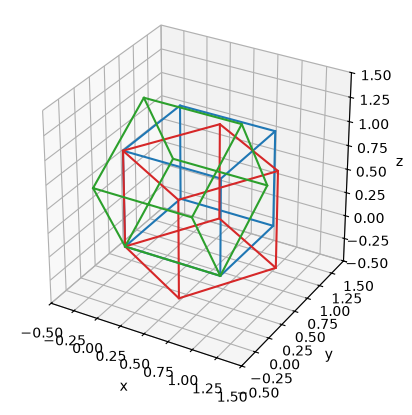

In [10]:
krychle = np.array(
    [[0, 0, 0], #0
    [1, 0, 0], #1
    [1, 1, 0], #2
    [0, 1, 0], #3
    [0, 0, 0], #4
    [0, 0, 1], #5
    [1, 0, 1], #6
    [1, 1, 1], #7
    [0, 1, 1], #8
    [0, 0, 1]], dtype=float
)

def nakresli_krychli(ax, transformace=None, color='tab:blue'):
    if transformace is None:
        transformace = np.diag([1,1,1])
    _krychle = (transformace @ krychle.T).T # @ znaci maticove nasobeni, .T transpozici

    ax.plot(_krychle[:,0], _krychle[:,1], _krychle[:,2], color=color)
    #bocne hrany
    ax.plot(_krychle[[1,6],0], _krychle[[1,6],1], _krychle[[1,6],2], color=color)
    ax.plot(_krychle[[2,7],0], _krychle[[2,7],1], _krychle[[2,7],2], color=color)
    ax.plot(_krychle[[3,8],0], _krychle[[3,8],1], _krychle[[3,8],2], color=color)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

fig = plt.figure()
ax3d = fig.add_subplot(projection='3d')
ax3d.grid()
ax3d.set_xlim(-0.5, 1.5)
ax3d.set_ylim(-0.5, 1.5)
ax3d.set_zlim(-0.5, 1.5)
ax3d.set_aspect('equal')
nakresli_krychli(ax3d)

alpha = 30 / 180 * np.pi
rotace = np.array(
    [[np.cos(alpha), np.sin(alpha), 0],
    [-np.sin(alpha), np.cos(alpha), 0],
    [0, 0, 1]]
)

rotace_x = np.array(
    [[1, 0, 0],
     [0, np.cos(alpha), -np.sin(alpha)],
     [0, np.sin(alpha), np.cos(alpha)]]
)

nakresli_krychli(ax3d, rotace, 'tab:red')
nakresli_krychli(ax3d, rotace_x, 'tab:green')


## Skoseni

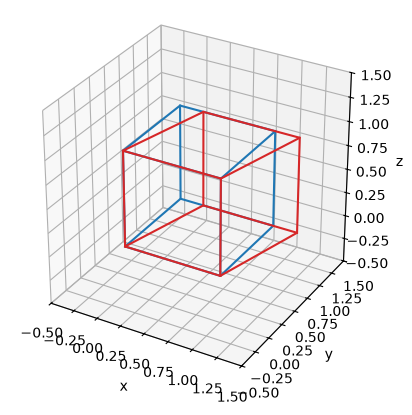

In [12]:
fig = plt.figure()
ax3d = fig.add_subplot(projection='3d')
ax3d.grid()
ax3d.set_xlim(-0.5, 1.5)
ax3d.set_ylim(-0.5, 1.5)
ax3d.set_zlim(-0.5, 1.5)
ax3d.set_aspect('equal')
nakresli_krychli(ax3d)

skoseni = np.array(
    [[1, 0.25, 0],
    [0, 1, 0],
    [0, 0, 1]]
)
nakresli_krychli(ax3d, skoseni, 'tab:red')


## Skalovani

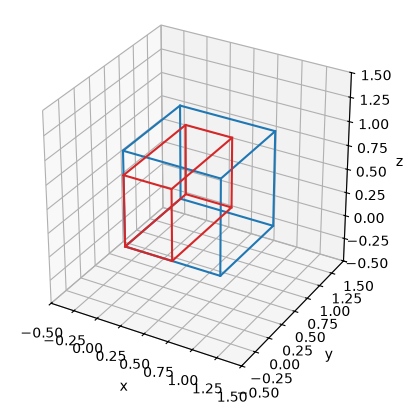

In [13]:
fig = plt.figure()
ax3d = fig.add_subplot(projection='3d')
ax3d.grid()
ax3d.set_xlim(-0.5, 1.5)
ax3d.set_ylim(-0.5, 1.5)
ax3d.set_zlim(-0.5, 1.5)
ax3d.set_aspect('equal')
nakresli_krychli(ax3d)

skalovani = np.array(
    [[0.5, 0, 0],
    [0, 1.1, 0],
    [0, 0, 0.75]]
)
nakresli_krychli(ax3d, skalovani, 'tab:red')


## Slozena transformace

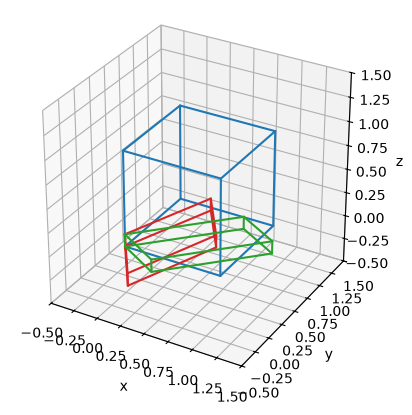

In [14]:
fig = plt.figure()
ax3d = fig.add_subplot(projection='3d')
ax3d.grid()
ax3d.set_xlim(-0.5, 1.5)
ax3d.set_ylim(-0.5, 1.5)
ax3d.set_zlim(-0.5, 1.5)
ax3d.set_aspect('equal')
nakresli_krychli(ax3d)

skalovani = np.array(
    [[0.5, 0, 0],
    [0, 1.1, 0],
    [0, 0, 0.13]]
)
nakresli_krychli(ax3d, skalovani @ skoseni @ rotace, 'tab:red')
# POZOR zalezi na poradi operaci (nasobeni  matic neni komutativni)
nakresli_krychli(ax3d, rotace @ skoseni @ skalovani, 'tab:green')
